In [1]:
import numpy as np
import params
from basis import *
from matplotlib import pyplot as plt

import matplotlib.ticker as ticker


In [2]:
params.stsp.reactions.St.shape

(15, 4)

In [3]:
def remake_cases(bog,allo):
    cases=[]
    for (b,a) in zip(bog,allo):
        if np.isnan(a):
            void,cs = params.create_cases(b,a)
        else:
            cs,void = params.create_cases(b,a)
        cases.append(cs)
        
    return cases

In [4]:
p_steady = np.loadtxt('fixed_steady/steady.csv')
bog,allo = np.loadtxt('fixed_steady/params.csv').T
cases = remake_cases(bog,allo)

In [7]:

S_steady  = [   expected(*marginalize(p_st, case.states, 3) ) for p_st,case in zip(p_steady,cases)]
MI_steady = [mutual_info(*marginalize(p_st, case.states, [0,1]) ) for p_st,case in zip(p_steady,cases)]

In [8]:
bog_list, ind = np.unique(bog,return_inverse= True)
allo = allo.reshape((bog_list.size,-1))
S_steady = np.array(S_steady).reshape((bog_list.size,-1))
MI_steady = np.array(MI_steady).reshape((bog_list.size,-1))

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))


[ax.plot(al[:-1],MI[:-1],label=r'$\beta / \gamma ={}$'.format(bog)) for al,MI,bog in zip(allo,MI_steady,bog_list) ]
[ax.scatter(al[:-1],MI[:-1],label=r'$\beta / \gamma ={}$'.format(bog)) for al,MI,bog in zip(allo,MI_steady,bog_list) ]


plt.xlabel(r' Allo rate')
plt.xscale('log')
ax.set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()

Error in callback <function flush_figures at 0x7f3785104dc0> (for post_execute):


KeyboardInterrupt: 

In [ ]:
np.linspace(-3,3,33)

array([-3.    , -2.8125, -2.625 , -2.4375, -2.25  , -2.0625, -1.875 ,
       -1.6875, -1.5   , -1.3125, -1.125 , -0.9375, -0.75  , -0.5625,
       -0.375 , -0.1875,  0.    ,  0.1875,  0.375 ,  0.5625,  0.75  ,
        0.9375,  1.125 ,  1.3125,  1.5   ,  1.6875,  1.875 ,  2.0625,
        2.25  ,  2.4375,  2.625 ,  2.8125,  3.    ])

In [ ]:
MI_steady

array([[4.89977306e-05, 4.78896081e-05, 4.46692126e-05, 3.66702737e-05,
        2.27254403e-05, 8.95280394e-06, 2.04807004e-06, 2.12004351e-06,
        7.52282532e-06, 2.66197513e-05, 6.97646539e-05, 8.94079955e-05,
        9.48683578e-05, 9.48683578e-05],
       [8.26318751e-05, 8.08943914e-05, 7.58359408e-05, 6.32109694e-05,
        4.09682474e-05, 1.85700052e-05, 6.67496482e-06, 5.40249390e-06,
        1.40218239e-05, 6.25477976e-05, 1.21061194e-04, 1.40119215e-04,
        1.44694631e-04, 1.44694631e-04],
       [2.56440440e-04, 2.51845487e-04, 2.38422023e-04, 2.04616088e-04,
        1.43985060e-04, 8.18166381e-05, 5.01427133e-05, 4.58502749e-05,
        5.73750385e-05, 1.87068545e-04, 2.43254062e-04, 2.54377546e-04,
        2.56159244e-04, 2.56159244e-04]])

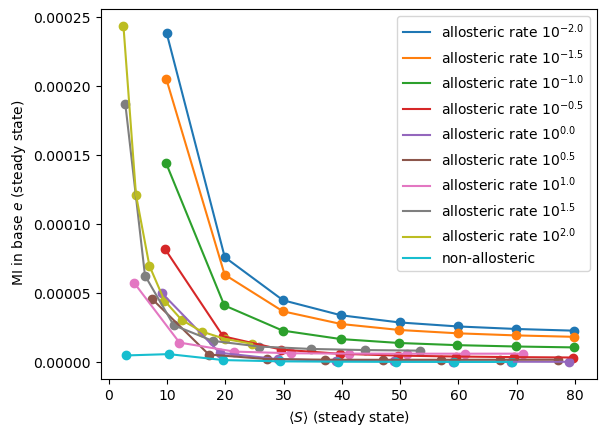

In [ ]:
S_steady_per_rate = np.array(S_steady_allo).T
MI_steady_per_rate = np.array(MI_steady_allo).T

[plt.plot(S,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],
                                                                                          MI_steady_per_rate[2:-2],
                                                                                          allo_rate_list[2:-2])]
[plt.scatter(S,MI) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]
plt.scatter(S_steady_nonallo,MI_steady_nonallo)
plt.plot(S_steady_nonallo,MI_steady_nonallo,label='non-allosteric')
plt.xlabel(r'$\langle S \rangle $ (steady state)')
plt.ylabel(' MI in base $e$ (steady state)')
plt.legend()

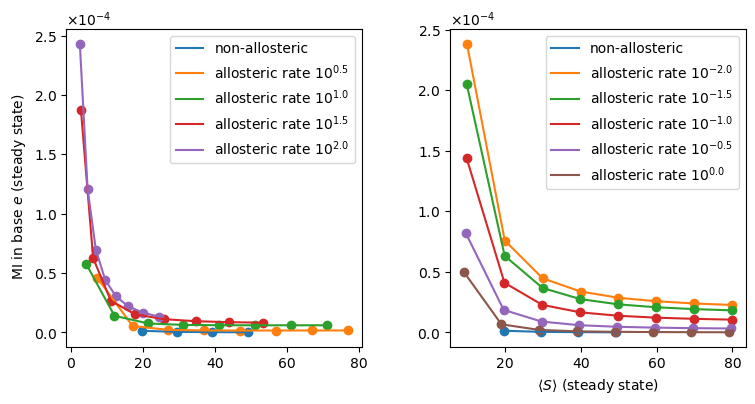

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

S_steady_per_rate = np.array(S_steady_allo).T
MI_steady_per_rate = np.array(MI_steady_allo).T

[axi.scatter(S_steady_nonallo[2:-2],MI_steady_nonallo[2:-2]) for axi in ax]
[axi.plot(S_steady_nonallo[2:-2],MI_steady_nonallo[2:-2],label='non-allosteric') for axi in ax]

[ax[0].plot(S,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) if rate>1 else ax[1].plot(S,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],
                                                                                          MI_steady_per_rate[2:-2],
                                                                                          allo_rate_list[2:-2])]
[ax[0].scatter(S,MI)  if rate>1 else ax[1].scatter(S,MI) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]

[axi.legend() for axi in ax]
plt.xlabel(r'$\langle S \rangle $ (steady state)')
ax[0].set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

for axi in ax:
    # Set the y-axis to scientific notation
    axi.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    axi.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


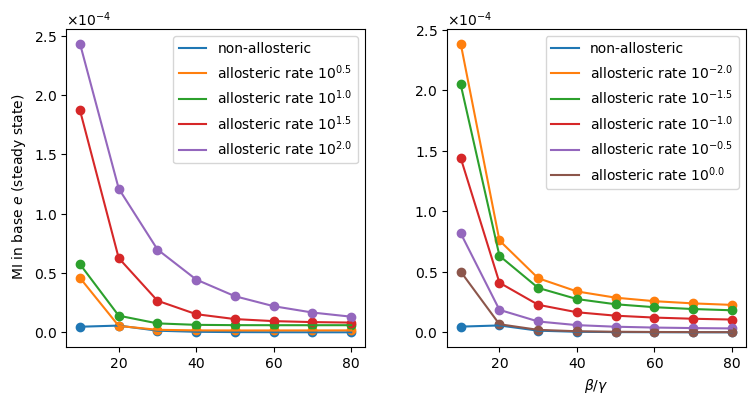

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

S_steady_per_rate = np.array(S_steady_allo).T
MI_steady_per_rate = np.array(MI_steady_allo).T

[axi.scatter(bog_list,MI_steady_nonallo) for axi in ax]
[axi.plot(bog_list,MI_steady_nonallo,label='non-allosteric') for axi in ax]

[ax[0].plot(bog_list,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) if rate>1 else ax[1].plot(bog_list,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],
                                                                                                                                                                                                                  MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]
[ax[0].scatter(bog_list,MI)  if rate>1 else ax[1].scatter(bog_list,MI) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]

[axi.legend() for axi in ax]
plt.xlabel(r'$\beta / \gamma$')
ax[0].set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

for axi in ax:
    # Set the y-axis to scientific notation
    axi.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    axi.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


In [ ]:
np.nan

nan